In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


## Procesamiento de los datos para Machine Learning
## Aplicar las tecnicas principales de preprocesamiento de datos para preparar un dataset antes del entreamiento

## Parte 1. Comprension del problema

Trabajeremos con el dataset de titanic, para construir un modelo que sea capaz de predecir si una persona sobrevive o no.

In [6]:
# Importamos las librerías
import pandas as pd
import numpy as np

# Librerías de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Librerías para graficar
import seaborn as sns
import matplotlib.pyplot as plt

# Librería de Kaggle
import kagglehub

C:\Users\angel\anaconda3\envs\extraccion\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
#Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path #Imprimimos la ruta

100%|██████████| 22.0k/22.0k [00:00<00:00, 1.74MB/s]

Extracting files...


'C:\\Users\\angel\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [8]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv") #Creamos el dataframe

In [9]:
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Parte 2. Seleccion de variables predictoras y variable Objetivo

La variable objetivo sera: Survived
donde 0 = No sobrevivio 1 = Sobrevivio

In [11]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [13]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Parte 3. Correlacion e hipotesis.
vamos a identificar la relacion entre variables numericas.
 nota: La correlacion No representa la importancia REAL de la variable en el modelo.

In [14]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Parch",
    "Fare"
]

In [15]:
corr = dfTitanic[variables_numericas].corr() #Creamos la matriz de correlacion corr

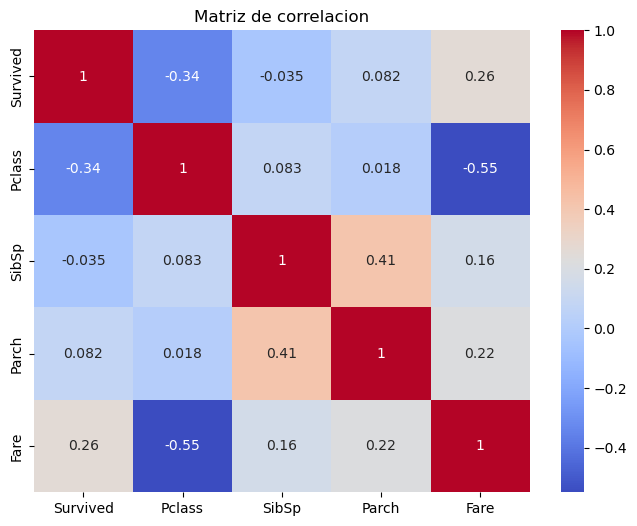

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show()

## Parte 4. Variables predictoras.

x --> Aquellas variablesque nos ayudan a predecir

y --> Variable objetivo

In [19]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [20]:
columnas= [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]

In [28]:
x = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [29]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='str')

In [30]:
y.name #Objetivo

'Survived'

## Parte 5. Limpieza de los datos

Realizamos la imputacion de los datos, donde existan valores nulos.

In [34]:
# Revisamos si existen valores nulos
x.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [36]:
#Vamos a imputar los datos para el campo edad
x["Age"] = x["Age"].fillna(
    x["Age"].median()
)

In [37]:
#Vamoos imputar los datos para el campo embarked, calculando la moda
x["Embarked"] = x["Embarked"].fillna(
    x["Embarked"].mode()[0]
)

In [38]:
x.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

## Parte 6: Normalizamos los datos categoricos (texto)
Los algoritmos de ML no entienden texto

In [39]:
X.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [40]:
X= pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first=True
)

In [41]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


## Parte 7. Division de los datos 

No debemos entrenar y evalut utilizando los mismos datos

80% para entrenar

20% para evaluar

In [42]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [43]:
print("Entrenamiento X: ", x_train.shape)

Entrenamiento X:  (712, 5)


In [45]:
print("Prueba X: ", x_test.shape)

Prueba X:  (179, 5)


In [46]:
print("Entrenamiento Y: ", y_train.shape)

Entrenamiento Y:  (712,)


In [47]:
print("Prueba Y: ", y_test.shape)

Prueba Y:  (179,)
